In [ ]:
%cd /content/drive/MyDrive/DeepLearning/FinalProject

/content/drive/MyDrive/DeepLearning/FinalProject


In [ ]:
! pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvj

In [ ]:
import pandas as pd
import torch
from utils.dataset import load_split_data, slice_into_windows, WindowedNoteDataset
from torch.utils.data import DataLoader
import json
import matplotlib.pyplot as plt

In [ ]:
def get_ids_from_split(split_csv_path):
    df = pd.read_csv(split_csv_path)
    train_ids = df[df["split"] == "train"]["id"].astype(str).tolist()
    val_ids = df[df["split"] == "val"]["id"].astype(str).tolist()
    test_ids = df[df["split"] == "test"]["id"].astype(str).tolist()
    return train_ids, val_ids, test_ids


In [ ]:
# ====== LOAD SPLIT IDS ======
train_ids, val_ids, test_ids = get_ids_from_split("data_processing/bach_piece_splits.csv")


# ====== LOAD DATA ======
X_train, Y_train = load_split_data("cqt", train_ids, split="train", use_fraction=1.0)
X_val, Y_val = load_split_data("cqt", val_ids, split="val")
X_test, Y_test = load_split_data("cqt", test_ids, split="test")

# ====== SLICE INTO WINDOWS ======
X_train, Y_train = slice_into_windows(X_train, Y_train, window_size=512, stride=256)
X_val, Y_val = slice_into_windows(X_val, Y_val, window_size=512, stride=256)
X_test, Y_test = slice_into_windows(X_test, Y_test, window_size=512, stride=256)

# ====== CREATE DATALOADERS ======
train_loader = DataLoader(WindowedNoteDataset(X_train, Y_train), batch_size=128,
                          shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(WindowedNoteDataset(X_val, Y_val), batch_size=128,
                        shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(WindowedNoteDataset(X_test, Y_test), batch_size=128,
                         shuffle=False, num_workers=4, pin_memory=True)

In [ ]:
from utils.dataset import load_split_data
import numpy as np

# Change this to "wav2vec" if needed
input_type = "cqt"
fps = 89 if input_type == "cqt" else 50

# Load split IDs
train_ids, val_ids, test_ids = get_ids_from_split("data_processing/bach_piece_splits.csv")

# Helper to get total frames for a split
def get_frame_count(split_name, ids):
    X, _ = load_split_data(input_type, ids, split=split_name)
    return X.shape[0]

# Compute frames per split
train_frames = get_frame_count("train", train_ids)
val_frames = get_frame_count("val", val_ids)
test_frames = get_frame_count("test", test_ids)
total_frames = train_frames + val_frames + test_frames

print(f"Train frames: {train_frames} ({train_frames/fps:.1f} seconds)")
print(f"Val frames: {val_frames} ({val_frames/fps:.1f} seconds)")
print(f"Test frames: {test_frames} ({test_frames/fps:.1f} seconds)")
print(f"Total frames: {total_frames} ({total_frames/fps:.1f} seconds)")



Train frames: 278976 (3134.6 seconds)
Val frames: 61464 (690.6 seconds)
Test frames: 72568 (815.4 seconds)
Total frames: 413008 (4640.5 seconds)


In [ ]:
def compute_pos_weight(Y_train_tensor):
    """
    Fast, clean vectorized computation of pos_weight.
    """
    note_freq = Y_train_tensor.sum(dim=0)  # sum over frames
    total_frames = Y_train_tensor.shape[0]

    # Avoid division by zero: mask
    pos_weight = (total_frames - note_freq) / (note_freq + 1e-5)

    # Set pos_weight = 0 for notes that never appear
    pos_weight = torch.where(note_freq > 0, pos_weight, torch.zeros_like(pos_weight))

    return pos_weight




In [ ]:
# After slicing into windows
import torch


# Flatten windows
Y_train_tensor = torch.tensor(Y_train).reshape(-1, 88)  # Merge 1088 windows × 512 frames into 1D frames
Y_val_tensor = torch.tensor(Y_val).reshape(-1, 88)
Y_test_tensor = torch.tensor(Y_test).reshape(-1, 88)

# Compute note frequencies

# Sum across all frames
note_freq_train = Y_train_tensor.sum(dim=0).cpu().numpy()
note_freq_val = Y_val_tensor.sum(dim=0).cpu().numpy()
note_freq_test = Y_test_tensor.sum(dim=0).cpu().numpy()



Converted Y_train to tensor
torch.Size([557056, 88])


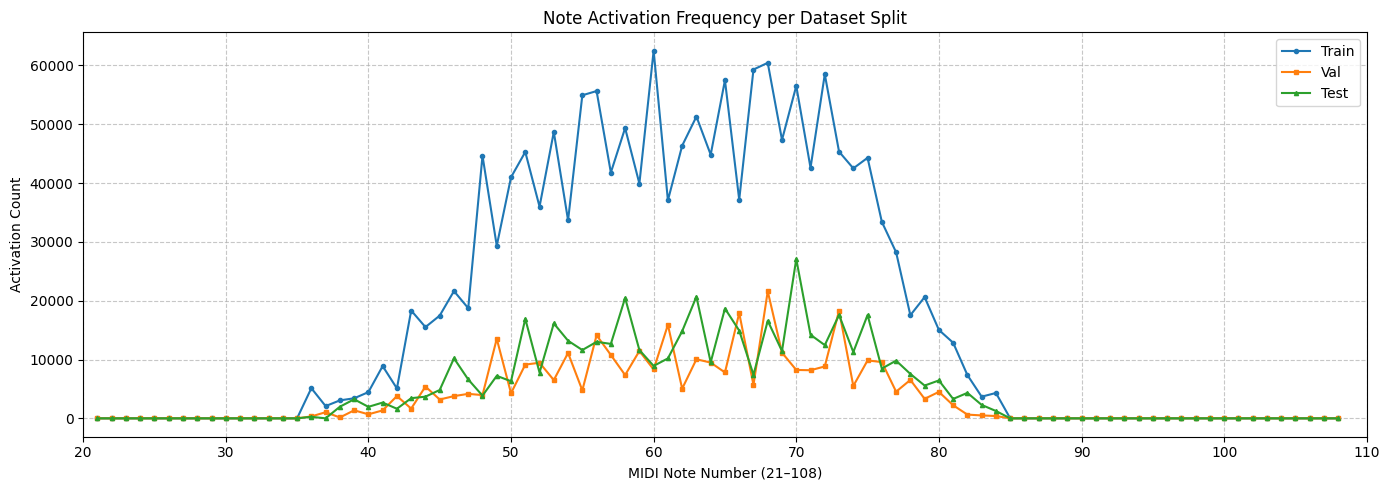

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
midi_notes = np.arange(21, 109)

def plot_note_distributions(train_freq, val_freq, test_freq):

    plt.figure(figsize=(14, 5))
    plt.plot(midi_notes, train_freq, label="Train", marker='o', markersize=3, linewidth=1.5)
    plt.plot(midi_notes, val_freq, label="Val", marker='s', markersize=3, linewidth=1.5)
    plt.plot(midi_notes, test_freq, label="Test", marker='^', markersize=3, linewidth=1.5)
    plt.title("Note Activation Frequency per Dataset Split")
    plt.xlabel("MIDI Note Number (21–108)")
    plt.ylabel("Activation Count")
    plt.xlim(20, 110)  # keep the x-axis tightly around the MIDI range
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
# Your graph
plot_note_distributions(note_freq_train, note_freq_val, note_freq_test)


In [ ]:

# Imbalance ratio
nonzero_freq = note_freq_train[note_freq_train > 0]
imbalance_ratio = nonzero_freq.max() / (nonzero_freq.min() + 1e-5)
print(f"Imbalance ratio (train set, non-zero notes only): {imbalance_ratio:.2f}")



Imbalance ratio (train set, non-zero notes only): 30.02


In [ ]:

# Number of notes never activated
num_never_activated = (note_freq_train == 0).sum()
print(f"Number of notes never activated in training set: {num_never_activated}")

Number of notes never activated in training set: 39


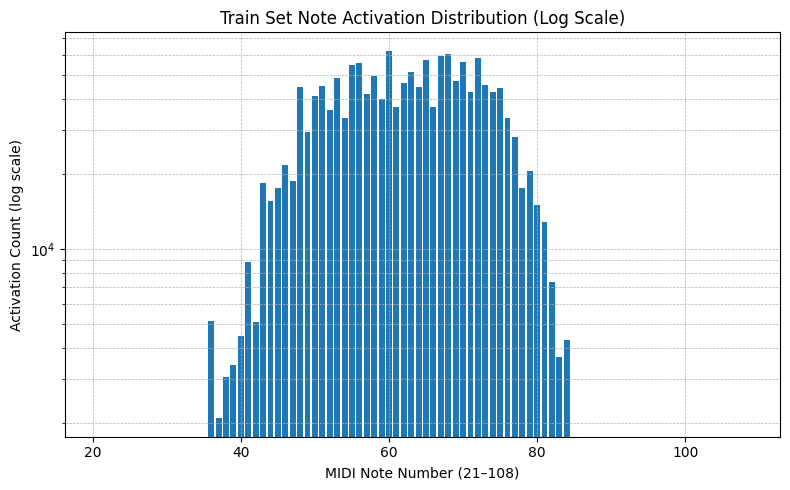

In [ ]:

# Log scale bar plot
plt.figure(figsize=(8,5))
plt.bar(midi_notes, note_freq_train)
plt.yscale('log')
plt.xlabel('MIDI Note Number (21–108)')
plt.ylabel('Activation Count (log scale)')
plt.title('Train Set Note Activation Distribution (Log Scale)')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()


In [ ]:
print(Y_train_tensor.shape)  # should now be (556416, 88) or similar

# Compute pos_weight
pos_weight = compute_pos_weight(Y_train_tensor)



loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to("cpu"))

torch.Size([557056, 88])


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pos_weight(pos_weight):
    midi_notes = np.arange(21, 109)

    plt.figure(figsize=(14,5))
    plt.plot(midi_notes, pos_weight.cpu().numpy(), marker='o')
    plt.title("Positional Weight per MIDI Note (Before Training)")
    plt.xlabel("MIDI Note Number (21–108)")
    plt.ylabel("Positional Weight")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


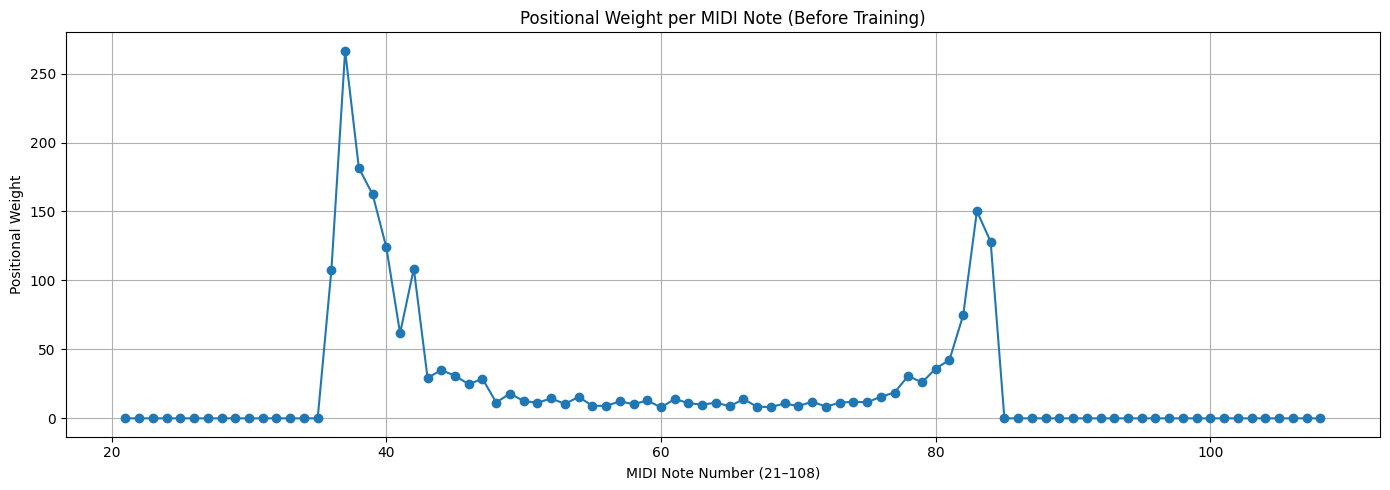

In [ ]:
plot_pos_weight(pos_weight)

In [ ]:
pos_weight.size()

torch.Size([512, 88])

In [ ]:
print(f"pos_weight stats:")
print(f"Min: {pos_weight.min().item():.2f}")
print(f"Max: {pos_weight.max().item():.2f}")
print(f"Mean: {pos_weight.mean().item():.2f}")
print(f"Std: {pos_weight.std().item():.2f}")


pos_weight stats:
Min: 0.00
Max: 266.99
Mean: 22.75
Std: 46.25


In [ ]:
pos_weight.size()

torch.Size([512, 88])

# Testing with no pos weight - baseline
0.5 of dataset for speed

In [ ]:

! python main.py Tranformer


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
Using normal BCEWithLogitsLoss (no pos_weight
[Threshold = 0.30] Active F1: 0.0288 | Precision: 0.0195 | Recall: 0.1437
Epoch 1: Loss=0.4631, Val Active F1=0.0288
Skipping early stopping check for warmup epoch 1 (F1=0.0288)
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 2: Loss=0.2852, Val Active F1=0.0000
Skipping early stopping check for warmup epoch 2 (F1=0.0000)
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 3: Loss=0.2174, Val Active F1=0.0000
Skipping early stopping check for warmup epoch 3 (F1=0.0000)
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 4: Loss=0.1752, Val Active F1=0.0000
Skipping early stopping

Training Configuration
Model: transformer
Input Type: cqt
Model Dimension: 256
Num Layers: 3
Num Heads: 4
Dropout: 0.3
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 300
Best Val F1: 0.6707
Best Val Epoch: 223


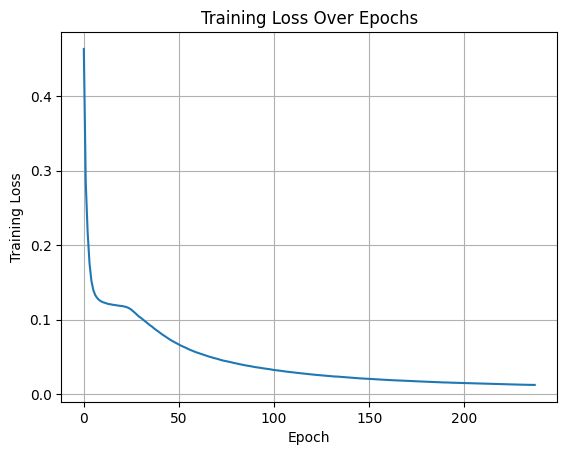

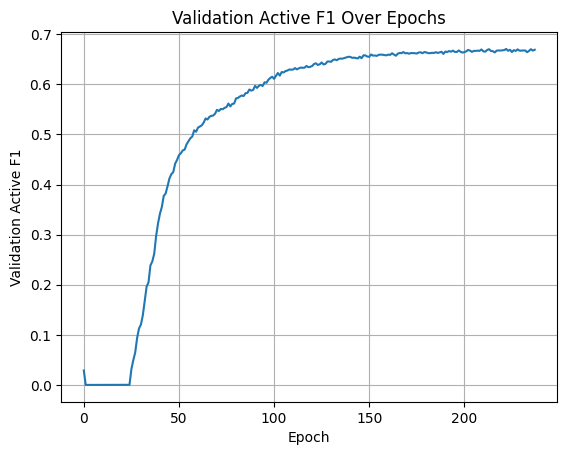

In [ ]:
with open("logs/Tranformer/Tranformer_260425_132124.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)

In [ ]:
from utils.metrics import evaluate_model_threshold_sweep


In [ ]:
from models.transformer import TinyTransformer  # or wherever you defined it

# Rebuild model
model = TinyTransformer(
    input_dim=88,   # or 768 if wav2vec input
    model_dim=256,
    num_heads=4,
    num_layers=3,
    output_dim=88,
    dropout=0.3
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
checkpoint_path = "/content/drive/MyDrive/DeepLearning/FinalProject/checkpoints/Tranformer_260425_132124/best.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model = model.to(device)
model.device = device  # <--- ADD THIS LINE

model.eval()

TinyTransformer(
  (input_proj): Linear(in_features=88, out_features=256, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=2048, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=2048, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (output_proj): Linear(in_features=256, out_features=88, bias=True)
)

In [ ]:
import numpy as np

# Assume you have your model and val_loader loaded
thresholds = np.linspace(0.1, 0.9, 17)  # thresholds from 0.1, 0.15, ..., 0.9

sweep_results = evaluate_model_threshold_sweep(model, val_loader, thresholds)

[Threshold = 0.10] Active F1: 0.6605 | Precision: 0.6130 | Recall: 0.7346
[Threshold = 0.15] Active F1: 0.6712 | Precision: 0.6530 | Recall: 0.7058
[Threshold = 0.20] Active F1: 0.6729 | Precision: 0.6775 | Recall: 0.6826
[Threshold = 0.25] Active F1: 0.6724 | Precision: 0.6969 | Recall: 0.6638
[Threshold = 0.30] Active F1: 0.6707 | Precision: 0.7134 | Recall: 0.6478
[Threshold = 0.35] Active F1: 0.6666 | Precision: 0.7263 | Recall: 0.6317
[Threshold = 0.40] Active F1: 0.6622 | Precision: 0.7384 | Recall: 0.6170
[Threshold = 0.45] Active F1: 0.6583 | Precision: 0.7503 | Recall: 0.6037
[Threshold = 0.50] Active F1: 0.6540 | Precision: 0.7625 | Recall: 0.5908
[Threshold = 0.55] Active F1: 0.6481 | Precision: 0.7747 | Recall: 0.5771
[Threshold = 0.60] Active F1: 0.6406 | Precision: 0.7855 | Recall: 0.5624
[Threshold = 0.65] Active F1: 0.6326 | Precision: 0.7990 | Recall: 0.5472
[Threshold = 0.70] Active F1: 0.6231 | Precision: 0.8106 | Recall: 0.5309
[Threshold = 0.75] Active F1: 0.6101 |

### Best result:

[Threshold = 0.20] Active F1: 0.6729 | Precision: 0.6775 | Recall: 0.6826

# Testing Auto Pos-weight on 0.5 of dataset
0.5 for speed - does pos weight with no clamping

In [ ]:

! python main.py Tranformer


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
Using automatic pos_weight based on training labels
[Threshold = 0.30] Active F1: 0.0925 | Precision: 0.0502 | Recall: 0.8894
Epoch 1: Loss=0.9307, Val Active F1=0.0925
Skipping early stopping check for warmup epoch 1 (F1=0.0925)
[Threshold = 0.30] Active F1: 0.1037 | Precision: 0.0563 | Recall: 1.0000
Epoch 2: Loss=0.8168, Val Active F1=0.1037
Skipping early stopping check for warmup epoch 2 (F1=0.1037)
[Threshold = 0.30] Active F1: 0.1044 | Precision: 0.0566 | Recall: 0.9991
Epoch 3: Loss=0.7802, Val Active F1=0.1044
Skipping early stopping check for warmup epoch 3 (F1=0.1044)
[Threshold = 0.30] Active F1: 0.1061 | Precision: 0.0577 | Recall: 0.9925
Epoch 4: Loss=0.7515, Val Active F1=0.1061
Skipping early st

Training Configuration
Model: transformer
Input Type: cqt
Model Dimension: 256
Num Layers: 3
Num Heads: 4
Dropout: 0.3
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 300
Best Val F1: 0.6491
Best Val Epoch: 257


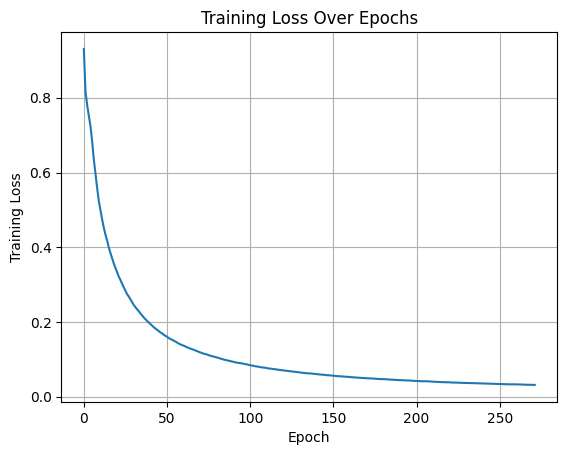

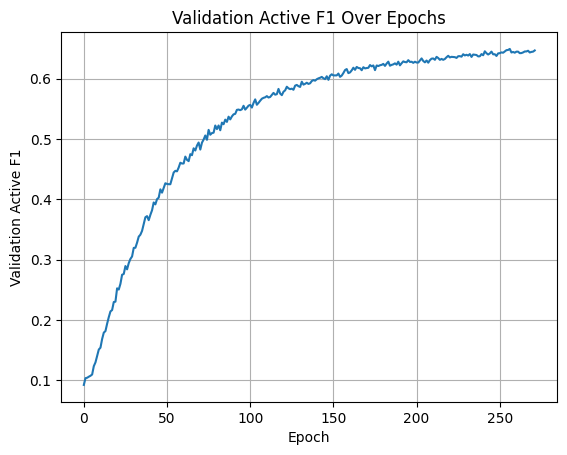

In [ ]:

with open("logs/Tranformer_pos_weights/Tranformer_260425_121455.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

In [ ]:
checkpoint_path = "/content/drive/MyDrive/DeepLearning/FinalProject/checkpoints/Tranformer_260425_121455/best.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model = model.to(device)
model.device = device  # <--- ADD THIS LINE

model.eval()



TinyTransformer(
  (input_proj): Linear(in_features=88, out_features=256, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=2048, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=2048, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (output_proj): Linear(in_features=256, out_features=88, bias=True)
)

In [ ]:
import numpy as np

# Assume you have your model and val_loader loaded
thresholds = np.linspace(0.1, 0.9, 17)  # thresholds from 0.1, 0.15, ..., 0.9

sweep_results = evaluate_model_threshold_sweep(model, val_loader, thresholds)


[Threshold = 0.10] Active F1: 0.5822 | Precision: 0.4640 | Recall: 0.8195
[Threshold = 0.15] Active F1: 0.6096 | Precision: 0.5039 | Recall: 0.8030
[Threshold = 0.20] Active F1: 0.6270 | Precision: 0.5328 | Recall: 0.7903
[Threshold = 0.25] Active F1: 0.6394 | Precision: 0.5555 | Recall: 0.7792
[Threshold = 0.30] Active F1: 0.6491 | Precision: 0.5750 | Recall: 0.7696
[Threshold = 0.35] Active F1: 0.6564 | Precision: 0.5913 | Recall: 0.7603
[Threshold = 0.40] Active F1: 0.6621 | Precision: 0.6060 | Recall: 0.7514
[Threshold = 0.45] Active F1: 0.6669 | Precision: 0.6195 | Recall: 0.7424
[Threshold = 0.50] Active F1: 0.6706 | Precision: 0.6321 | Recall: 0.7332
[Threshold = 0.55] Active F1: 0.6736 | Precision: 0.6447 | Recall: 0.7232
[Threshold = 0.60] Active F1: 0.6765 | Precision: 0.6574 | Recall: 0.7140
[Threshold = 0.65] Active F1: 0.6786 | Precision: 0.6701 | Recall: 0.7038
[Threshold = 0.70] Active F1: 0.6803 | Precision: 0.6833 | Recall: 0.6929
[Threshold = 0.75] Active F1: 0.6816 |

### Best result:

[Threshold = 0.80] Active F1: 0.6822 | Precision: 0.7139 | Recall: 0.6671

# Testing Pos-weight clamped at 100 on 0.5 of dataset
0.5 for speed - does pos weight with no clamping

In [ ]:

! python main.py Tranformer

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
Using clamped pos_weight (max 100) based on training labels
[Threshold = 0.30] Active F1: 0.0910 | Precision: 0.0494 | Recall: 0.8419
Epoch 1: Loss=0.9082, Val Active F1=0.0910
Skipping early stopping check for warmup epoch 1 (F1=0.0910)
[Threshold = 0.30] Active F1: 0.1051 | Precision: 0.0592 | Recall: 0.9624
Epoch 2: Loss=0.7899, Val Active F1=0.1051
Skipping early stopping check for warmup epoch 2 (F1=0.1051)
[Threshold = 0.30] Active F1: 0.1039 | Precision: 0.0564 | Recall: 0.9778
Epoch 3: Loss=0.7542, Val Active F1=0.1039
Skipping early stopping check for warmup epoch 3 (F1=0.1039)
[Threshold = 0.30] Active F1: 0.1063 | Precision: 0.0580 | Recall: 0.9570
Epoch 4: Loss=0.7288, Val Active F1=0.1063
Skipping 

In [ ]:
checkpoint_path = "/content/drive/MyDrive/DeepLearning/FinalProject/checkpoints/Tranformer_260425_125036/best.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model = model.to(device)
model.device = device

model.eval()



TinyTransformer(
  (input_proj): Linear(in_features=88, out_features=256, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=2048, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=2048, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (output_proj): Linear(in_features=256, out_features=88, bias=True)
)

In [ ]:
import numpy as np

# Assume you have your model and val_loader loaded
thresholds = np.linspace(0.1, 0.9, 17)  # thresholds from 0.1, 0.15, ..., 0.9

sweep_results = evaluate_model_threshold_sweep(model, val_loader, thresholds)

[Threshold = 0.10] Active F1: 0.5649 | Precision: 0.4361 | Recall: 0.8409
[Threshold = 0.15] Active F1: 0.5971 | Precision: 0.4789 | Recall: 0.8223
[Threshold = 0.20] Active F1: 0.6184 | Precision: 0.5108 | Recall: 0.8081
[Threshold = 0.25] Active F1: 0.6335 | Precision: 0.5361 | Recall: 0.7959
[Threshold = 0.30] Active F1: 0.6444 | Precision: 0.5569 | Recall: 0.7843
[Threshold = 0.35] Active F1: 0.6529 | Precision: 0.5749 | Recall: 0.7731
[Threshold = 0.40] Active F1: 0.6602 | Precision: 0.5918 | Recall: 0.7629
[Threshold = 0.45] Active F1: 0.6658 | Precision: 0.6072 | Recall: 0.7518
[Threshold = 0.50] Active F1: 0.6707 | Precision: 0.6221 | Recall: 0.7414
[Threshold = 0.55] Active F1: 0.6746 | Precision: 0.6363 | Recall: 0.7309
[Threshold = 0.60] Active F1: 0.6778 | Precision: 0.6500 | Recall: 0.7201
[Threshold = 0.65] Active F1: 0.6806 | Precision: 0.6645 | Recall: 0.7088
[Threshold = 0.70] Active F1: 0.6822 | Precision: 0.6790 | Recall: 0.6965
[Threshold = 0.75] Active F1: 0.6829 |

### Best result
[Threshold = 0.75] Active F1: 0.6829 | Precision: 0.6946 | Recall: 0.6822